# Comparative Analysis of CNN (ResNet) vs. Vision Transformers (ViT) for Medical Image Classification

**Deep Learning Course — Final Project**

---

## Objective

This project compares two fundamentally different deep learning architectures for classifying chest X-ray images as **Normal** or **Pneumonia**:

1. **ResNet-50** — A convolutional neural network that learns hierarchical spatial features through residual connections.
2. **Vision Transformer (ViT-B/16)** — A transformer-based architecture that models global relationships by treating image patches as tokens.

Both models use **transfer learning** from ImageNet pre-trained weights. We evaluate them on accuracy, F1-score, confusion matrices, and use **Grad-CAM** to visualize what regions of the X-ray the CNN attends to.

### Dataset
**Chest X-Ray Images (Pneumonia)** from Kaggle, organized into `train/`, `val/`, and `test/` splits with `NORMAL` and `PNEUMONIA` subfolders.

---
## 1. Setup & Installation

In [ ]:
!pip install -q torch torchvision timm scikit-learn matplotlib seaborn tqdm

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

import timm
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
)
from tqdm.auto import tqdm

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


---
## 2. Configuration

In [3]:
# ==================================================================
#  Configuration — adjust paths & hyperparameters
# ==================================================================

# Path to the root of the Chest X-Ray dataset.
# Expected structure:
#   DATA_DIR/
#     train/  -> NORMAL/, PNEUMONIA/
#     val/    -> NORMAL/, PNEUMONIA/
#     test/   -> NORMAL/, PNEUMONIA/
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/chest_xray'   # <-- UPDATE this to your dataset path

IMG_SIZE       = 224
BATCH_SIZE     = 32
NUM_WORKERS    = 2          # Set to 0 on Windows if you hit issues
NUM_EPOCHS     = 10
LEARNING_RATE  = 1e-4
WEIGHT_DECAY   = 1e-4
NUM_CLASSES    = 2
CLASS_NAMES    = ['NORMAL', 'PNEUMONIA']

---
## 3. Data Loading & Preprocessing

In [4]:
# ── ImageNet normalization constants ──
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training: data augmentation to reduce overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation / Test: deterministic preprocessing only
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [5]:
# ── Load datasets with ImageFolder ──
try:
    train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
    val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   transform=eval_transforms)
    test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=eval_transforms)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    print(f'Class mapping: {train_dataset.class_to_idx}')
    print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
except FileNotFoundError as e:
    print(f"Error: {e}")
    print(f"Please verify the DATA_DIR path and its contents: {DATA_DIR}")
    # Display directory contents for debugging
    print("Listing contents of DATA_DIR:")
    !ls -F "{DATA_DIR}"
    print("Listing contents of DATA_DIR/train:")
    !ls -F "{os.path.join(DATA_DIR, 'train')}"



Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train: 5216 | Val: 16 | Test: 624


### 3.1  Visualize Sample Images

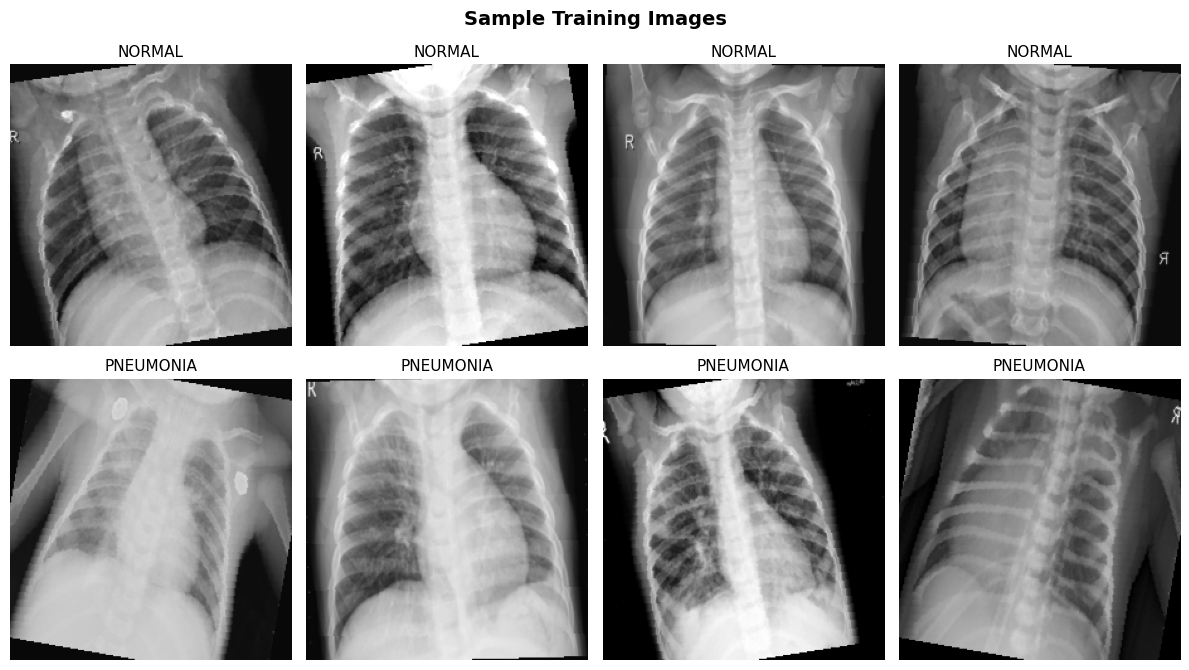

In [6]:
def show_sample_images(dataset, class_names, n=4):
    """Display a grid of sample images from each class."""
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 7))
    fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    for cls_idx in range(2):
        indices = [i for i, (_, label) in enumerate(dataset.samples) if label == cls_idx]
        chosen = random.sample(indices, min(n, len(indices)))
        for j, idx in enumerate(chosen):
            img, label = dataset[idx]
            img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
            axes[cls_idx, j].imshow(img)
            axes[cls_idx, j].set_title(class_names[label], fontsize=11)
            axes[cls_idx, j].axis('off')

    plt.tight_layout()
    plt.show()

show_sample_images(train_dataset, CLASS_NAMES)

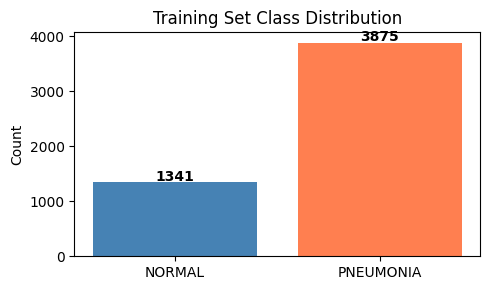

Class counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}


In [7]:
# ── Class distribution bar chart ──
train_labels = [label for _, label in train_dataset.samples]
counts = {CLASS_NAMES[i]: train_labels.count(i) for i in range(NUM_CLASSES)}

plt.figure(figsize=(5, 3))
bars = plt.bar(counts.keys(), counts.values(), color=['steelblue', 'coral'])
plt.title('Training Set Class Distribution')
plt.ylabel('Count')
for i, (k, v) in enumerate(counts.items()):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Class counts: {counts}')

---
## 4. Model Definitions

### 4.1  ResNet-50 (CNN Baseline)

We load a pre-trained ResNet-50, freeze the convolutional backbone to preserve learned low/mid-level features, and replace the final fully-connected head for binary classification.

In [8]:
def build_resnet(num_classes=2, freeze_backbone=True):
    """Build a ResNet-50 with transfer learning."""
    model = torchvision.models.resnet50(
        weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
    )
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classification head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes),
    )
    return model

resnet_model = build_resnet(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

total  = sum(p.numel() for p in resnet_model.parameters())
train_ = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f'ResNet-50  |  Total params: {total:,}  |  Trainable: {train_:,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


ResNet-50  |  Total params: 23,512,130  |  Trainable: 4,098


### 4.2  Vision Transformer (ViT-B/16)

We use the `timm` library to load a pre-trained ViT-B/16. The transformer splits the image into 16x16 patches, embeds them as tokens, and uses multi-head self-attention to capture long-range spatial dependencies — well-suited for detecting diffuse patterns like pneumonia across the lung field.

In [9]:
def build_vit(num_classes=2, freeze_backbone=True):
    """Build a ViT-B/16 with transfer learning via timm."""
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=num_classes,
    )
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False
    return model

vit_model = build_vit(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

total  = sum(p.numel() for p in vit_model.parameters())
train_ = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'ViT-B/16   |  Total params: {total:,}  |  Trainable: {train_:,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16   |  Total params: 85,800,194  |  Trainable: 1,538


---
## 5. Training Infrastructure

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns loss, accuracy, predictions, and true labels."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    total = len(all_labels)
    return (
        running_loss / total,
        accuracy_score(all_labels, all_preds),
        np.array(all_preds),
        np.array(all_labels),
    )

In [11]:
def train_model(model, train_loader, val_loader, num_epochs, lr, weight_decay,
                device, model_name='Model'):
    """
    Full training loop with:
      - AdamW optimizer
      - CrossEntropy loss
      - Cosine-annealing LR scheduler
      - Best-model checkpointing (by val accuracy)
    Returns the best model and a history dict.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = defaultdict(list)
    best_val_acc = 0.0
    best_state = None

    print(f'\n{"="*60}')
    print(f'  Training {model_name} for {num_epochs} epochs')
    print(f'{"="*60}')

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        marker = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            marker = '  *best*'

        print(f'  Epoch {epoch:02d}/{num_epochs}  |  '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{marker}')

    model.load_state_dict(best_state)
    print(f'\n  Best Val Accuracy: {best_val_acc:.4f}')
    return model, dict(history)

---
## 6. Train Both Models

### 6.1  Train ResNet-50

In [12]:
resnet_model, resnet_history = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE,
    model_name='ResNet-50',
)


  Training ResNet-50 for 10 epochs
  Epoch 01/10  |  Train Loss: 0.4904  Acc: 0.7429  |  Val Loss: 0.5898  Acc: 0.5625  *best*
  Epoch 02/10  |  Train Loss: 0.3884  Acc: 0.8023  |  Val Loss: 0.5038  Acc: 0.6250  *best*
  Epoch 03/10  |  Train Loss: 0.3374  Acc: 0.8702  |  Val Loss: 0.4645  Acc: 0.6875  *best*
  Epoch 04/10  |  Train Loss: 0.3052  Acc: 0.8932  |  Val Loss: 0.4151  Acc: 0.7500  *best*
  Epoch 05/10  |  Train Loss: 0.2863  Acc: 0.8961  |  Val Loss: 0.4504  Acc: 0.6875
  Epoch 06/10  |  Train Loss: 0.2752  Acc: 0.8993  |  Val Loss: 0.4003  Acc: 0.7500
  Epoch 07/10  |  Train Loss: 0.2686  Acc: 0.9061  |  Val Loss: 0.3903  Acc: 0.7500
  Epoch 08/10  |  Train Loss: 0.2621  Acc: 0.9045  |  Val Loss: 0.3955  Acc: 0.8125  *best*
  Epoch 09/10  |  Train Loss: 0.2568  Acc: 0.9105  |  Val Loss: 0.4036  Acc: 0.8125
  Epoch 10/10  |  Train Loss: 0.2590  Acc: 0.9089  |  Val Loss: 0.4161  Acc: 0.6875

  Best Val Accuracy: 0.8125


### 6.2  Train ViT-B/16

In [13]:
vit_model, vit_history = train_model(
    model=vit_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE,
    model_name='ViT-B/16',
)


  Training ViT-B/16 for 10 epochs
  Epoch 01/10  |  Train Loss: 0.4662  Acc: 0.7617  |  Val Loss: 0.5724  Acc: 0.6875  *best*
  Epoch 02/10  |  Train Loss: 0.2964  Acc: 0.8867  |  Val Loss: 0.4596  Acc: 0.7500  *best*
  Epoch 03/10  |  Train Loss: 0.2352  Acc: 0.9202  |  Val Loss: 0.3951  Acc: 0.8125  *best*
  Epoch 04/10  |  Train Loss: 0.2061  Acc: 0.9321  |  Val Loss: 0.3626  Acc: 0.8750  *best*
  Epoch 05/10  |  Train Loss: 0.1904  Acc: 0.9365  |  Val Loss: 0.3503  Acc: 0.8750
  Epoch 06/10  |  Train Loss: 0.1767  Acc: 0.9446  |  Val Loss: 0.3303  Acc: 0.8750
  Epoch 07/10  |  Train Loss: 0.1701  Acc: 0.9433  |  Val Loss: 0.3351  Acc: 0.8750
  Epoch 08/10  |  Train Loss: 0.1719  Acc: 0.9411  |  Val Loss: 0.3263  Acc: 0.8750
  Epoch 09/10  |  Train Loss: 0.1640  Acc: 0.9473  |  Val Loss: 0.3307  Acc: 0.8750
  Epoch 10/10  |  Train Loss: 0.1684  Acc: 0.9446  |  Val Loss: 0.3252  Acc: 0.8750

  Best Val Accuracy: 0.8750


---
## 7. Training Curves

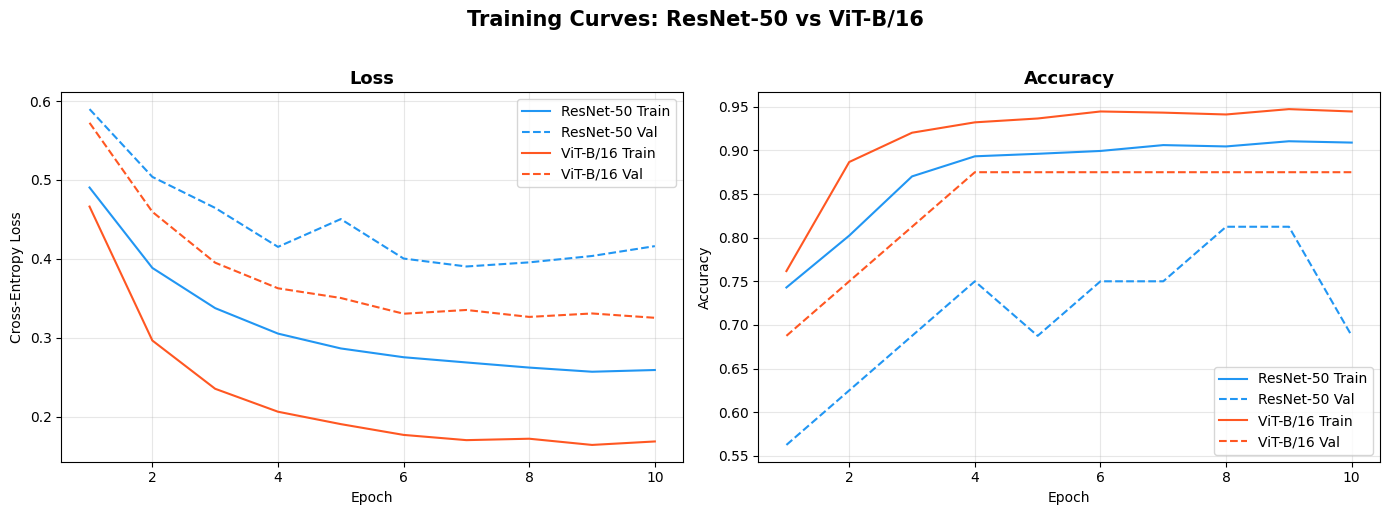

In [14]:
def plot_training_curves(histories, model_names):
    """Plot loss and accuracy curves for multiple models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#FF5722']

    for idx, (hist, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(hist['train_loss']) + 1)
        c = colors[idx]
        axes[0].plot(epochs, hist['train_loss'], '-',  color=c, label=f'{name} Train')
        axes[0].plot(epochs, hist['val_loss'],   '--', color=c, label=f'{name} Val')
        axes[1].plot(epochs, hist['train_acc'],  '-',  color=c, label=f'{name} Train')
        axes[1].plot(epochs, hist['val_acc'],    '--', color=c, label=f'{name} Val')

    axes[0].set_title('Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training Curves: ResNet-50 vs ViT-B/16',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_training_curves([resnet_history, vit_history], ['ResNet-50', 'ViT-B/16'])

---
## 8. Evaluation on Test Set

In [16]:
criterion = nn.CrossEntropyLoss()

resnet_loss, resnet_acc, resnet_preds, resnet_labels = evaluate(
    resnet_model, test_loader, criterion, DEVICE)
resnet_f1 = f1_score(resnet_labels, resnet_preds, average='weighted')

vit_loss, vit_acc, vit_preds, vit_labels = evaluate(
    vit_model, test_loader, criterion, DEVICE)
vit_f1 = f1_score(vit_labels, vit_preds, average='weighted')

print('=' * 55)
print(f'{"Model":<15} {"Accuracy":>10} {"F1-Score":>12} {"Loss":>10}')
print('-' * 55)
print(f'{"ResNet-50":<15} {resnet_acc:>10.4f} {resnet_f1:>12.4f} {resnet_loss:>10.4f}')
print(f'{"ViT-B/16":<15} {vit_acc:>10.4f} {vit_f1:>12.4f} {vit_loss:>10.4f}')
print('=' * 55)

Model             Accuracy     F1-Score       Loss
-------------------------------------------------------
ResNet-50           0.8317       0.8281     0.3936
ViT-B/16            0.8285       0.8183     0.3859


In [17]:
print('ResNet-50 Classification Report:')
print(classification_report(resnet_labels, resnet_preds, target_names=CLASS_NAMES))

print('\nViT-B/16 Classification Report:')
print(classification_report(vit_labels, vit_preds, target_names=CLASS_NAMES))

ResNet-50 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.83      0.69      0.76       234
   PNEUMONIA       0.83      0.92      0.87       390

    accuracy                           0.83       624
   macro avg       0.83      0.80      0.81       624
weighted avg       0.83      0.83      0.83       624


ViT-B/16 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.59      0.72       234
   PNEUMONIA       0.80      0.97      0.88       390

    accuracy                           0.83       624
   macro avg       0.86      0.78      0.80       624
weighted avg       0.84      0.83      0.82       624



### 8.1  Confusion Matrices

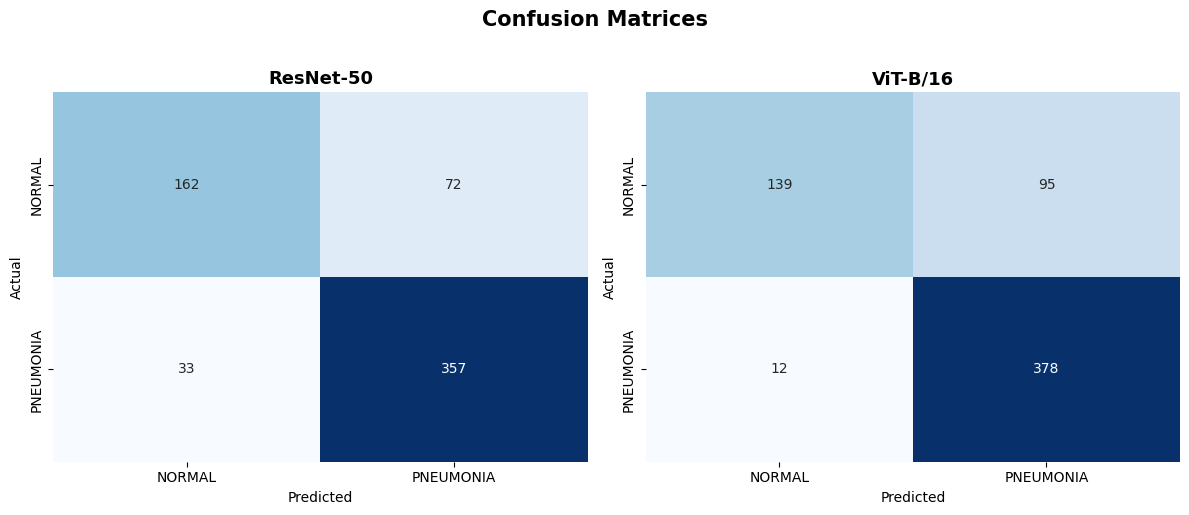

In [18]:
def plot_confusion_matrices(labels_list, preds_list, model_names, class_names):
    """Plot confusion matrices for multiple models side by side."""
    fig, axes = plt.subplots(1, len(model_names), figsize=(6 * len(model_names), 5))
    if len(model_names) == 1:
        axes = [axes]

    for ax, labels, preds, name in zip(axes, labels_list, preds_list, model_names):
        cm = confusion_matrix(labels, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, cbar=False)
        ax.set_title(name, fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(
    [resnet_labels, vit_labels],
    [resnet_preds, vit_preds],
    ['ResNet-50', 'ViT-B/16'],
    CLASS_NAMES,
)

### 8.2  Metric Comparison Bar Chart

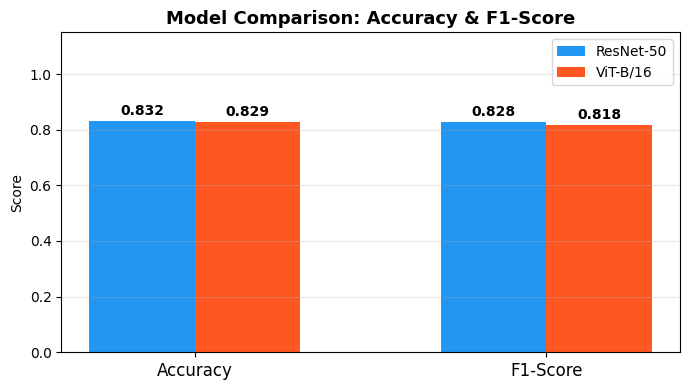

In [19]:
metrics = {'Accuracy': [resnet_acc, vit_acc], 'F1-Score': [resnet_f1, vit_f1]}
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, [metrics['Accuracy'][0], metrics['F1-Score'][0]],
               width, label='ResNet-50', color='#2196F3')
bars2 = ax.bar(x + width/2, [metrics['Accuracy'][1], metrics['F1-Score'][1]],
               width, label='ViT-B/16', color='#FF5722')

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy & F1-Score', fontsize=13, fontweight='bold')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f'{h:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Grad-CAM Visualization (ResNet-50)

**Gradient-weighted Class Activation Mapping (Grad-CAM)** highlights which regions of an input image most influence the model's prediction. For a chest X-ray classifier, we expect the heatmap to activate over the lung fields — especially where pneumonia-related opacities are present.

We hook into ResNet's final convolutional block (`layer4`) to capture feature maps and their gradients.

In [20]:
class GradCAM:
    """
    Grad-CAM implementation for CNN models.

    Hooks into a target convolutional layer to capture:
      - Forward:  feature map activations
      - Backward: gradients of the target class w.r.t. those activations

    Heatmap = ReLU( sum( global_avg_pool(gradients) * activations ) )
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        self.activations = out.detach()

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, target_class=None):
        """
        Generate a Grad-CAM heatmap.

        Args:
            input_tensor: (1, C, H, W) image tensor.
            target_class: class index (None = use predicted class).

        Returns:
            cam: normalized heatmap (H_feat, W_feat) in [0, 1].
        """
        self.model.eval()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()

        if cam.max() > 0:
            cam = cam / cam.max()
        return cam

In [21]:
def visualize_gradcam(model, dataset, grad_cam, device, class_names, n_images=8):
    """
    Show original X-ray, Grad-CAM heatmap, and overlay side by side.
    Selects a balanced mix of NORMAL and PNEUMONIA samples.
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    # Balanced sample selection
    normal_idx    = [i for i, (_, l) in enumerate(dataset.samples) if l == 0]
    pneumonia_idx = [i for i, (_, l) in enumerate(dataset.samples) if l == 1]
    half = n_images // 2
    chosen = (random.sample(normal_idx, min(half, len(normal_idx)))
              + random.sample(pneumonia_idx, min(half, len(pneumonia_idx))))

    fig, axes = plt.subplots(len(chosen), 3, figsize=(12, 4 * len(chosen)))
    if len(chosen) == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle('Grad-CAM Visualization (ResNet-50)',
                 fontsize=16, fontweight='bold', y=1.01)

    for row, idx in enumerate(chosen):
        img_tensor, true_label = dataset[idx]
        img_display = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        # Generate heatmap
        input_batch = img_tensor.unsqueeze(0).to(device)
        cam = grad_cam.generate(input_batch)
        cam_resized = F.interpolate(
            torch.tensor(cam).unsqueeze(0).unsqueeze(0),
            size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False,
        ).squeeze().numpy()

        # Get prediction
        with torch.no_grad():
            pred = model(input_batch).argmax(1).item()

        # Col 1: original
        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f'True: {class_names[true_label]}', fontsize=11)
        axes[row, 0].axis('off')

        # Col 2: heatmap
        axes[row, 1].imshow(cam_resized, cmap='jet')
        axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=11)
        axes[row, 1].axis('off')

        # Col 3: overlay
        axes[row, 2].imshow(img_display)
        axes[row, 2].imshow(cam_resized, cmap='jet', alpha=0.4)
        color = 'green' if pred == true_label else 'red'
        axes[row, 2].set_title(f'Pred: {class_names[pred]}', fontsize=11, color=color)
        axes[row, 2].axis('off')

    # Column headers on the first row
    for ax, header in zip(axes[0], ['Original X-Ray', 'Grad-CAM Heatmap', 'Overlay']):
        ax.set_title(header + '\n' + ax.get_title(), fontsize=11)

    plt.tight_layout()
    plt.show()

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


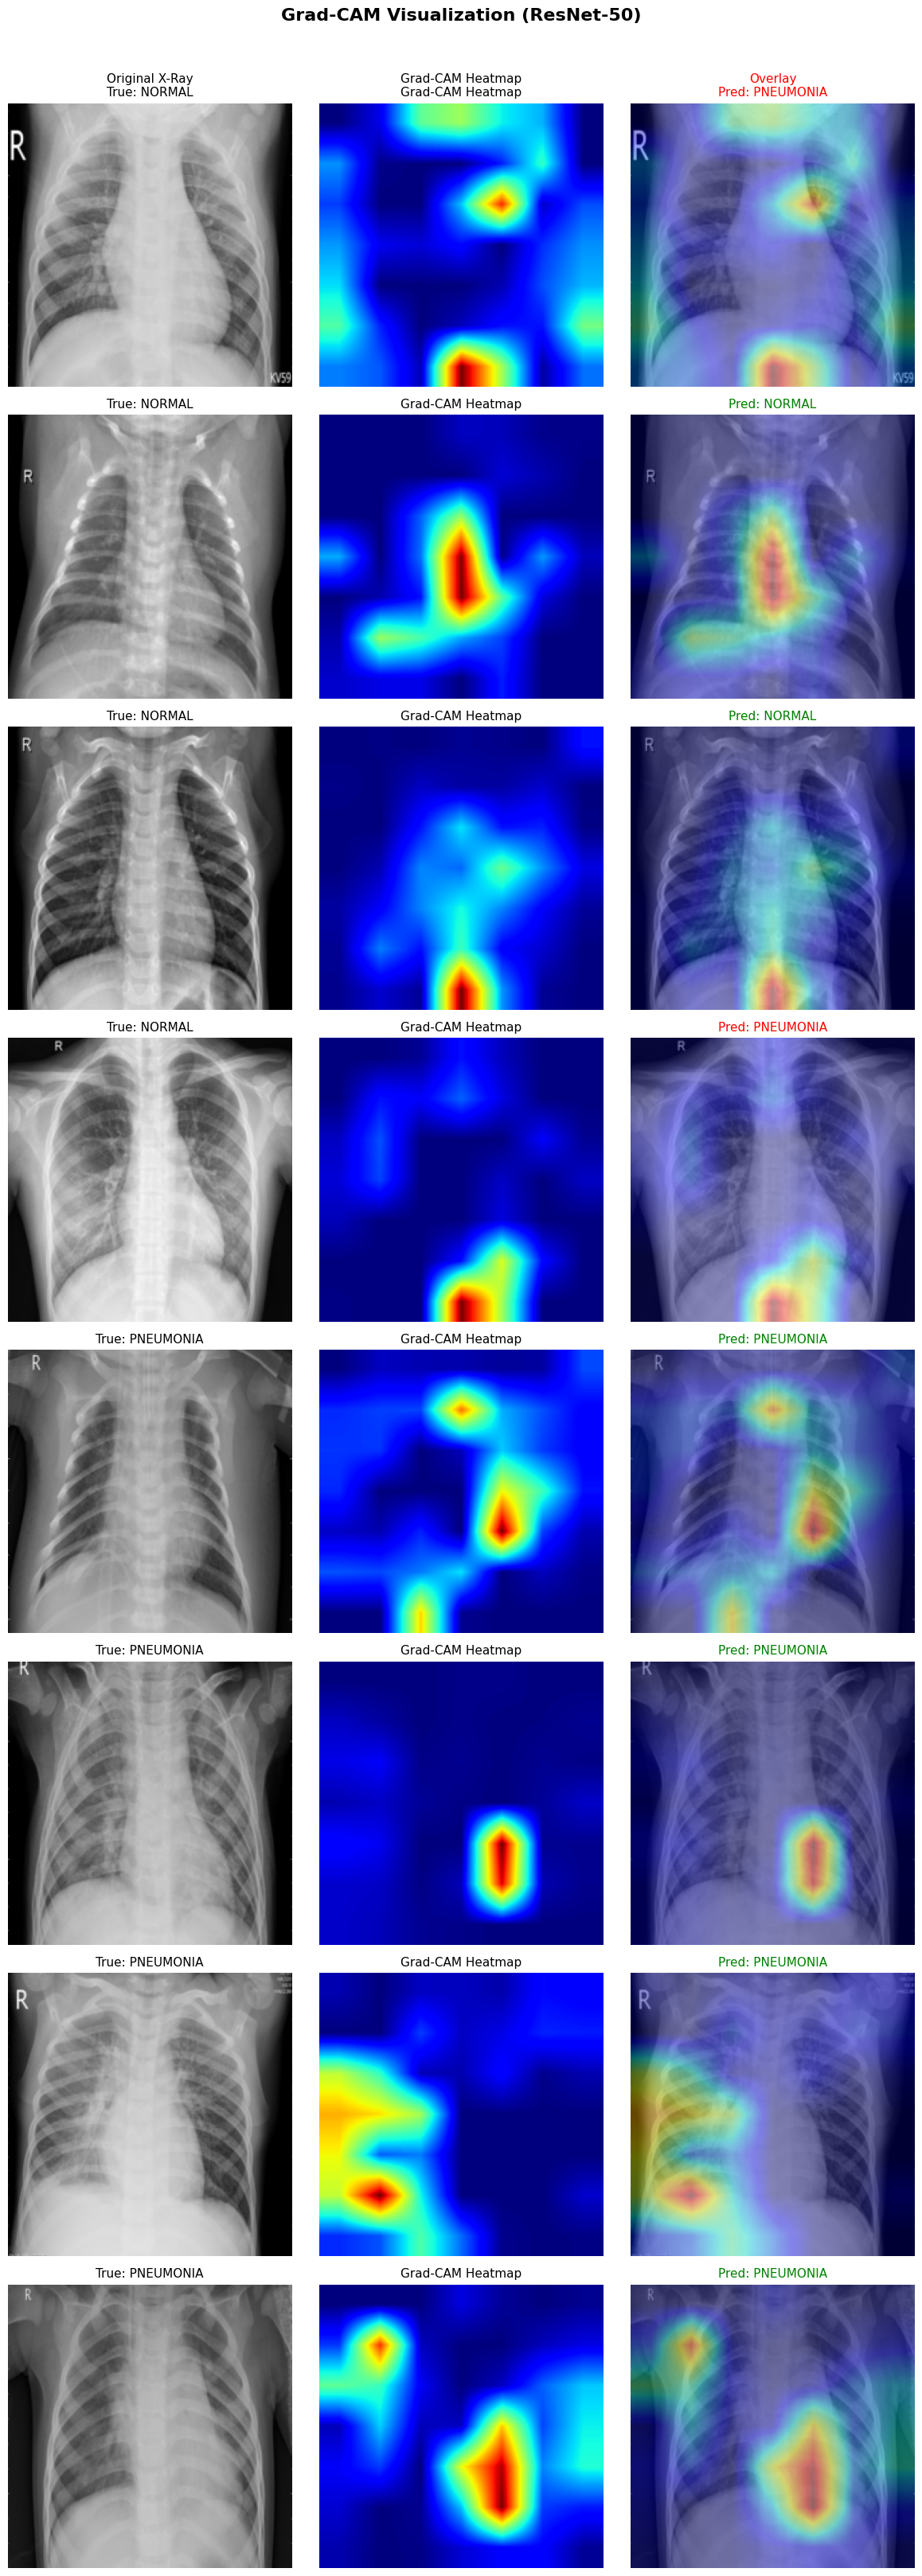

In [24]:
# Initialize Grad-CAM targeting ResNet's layer4 (final conv block)

# Temporarily unfreeze layer4 for Grad-CAM computation
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

grad_cam = GradCAM(resnet_model, resnet_model.layer4)

visualize_gradcam(
    model=resnet_model,
    dataset=test_dataset,
    grad_cam=grad_cam,
    device=DEVICE,
    class_names=CLASS_NAMES,
    n_images=8,
)

# Freeze layer4 parameters back to their original state (frozen)
for param in resnet_model.layer4.parameters():
    param.requires_grad = False

---
## 10. Summary & Conclusions

### Architecture Comparison

| Aspect | ResNet-50 (CNN) | ViT-B/16 (Transformer) |
|--------|----------------|------------------------|
| **Core mechanism** | Hierarchical convolutions + residual connections | Multi-head self-attention over 16x16 patches |
| **Inductive bias** | Strong locality & translation equivariance | Minimal — learns spatial structure from data |
| **Transfer learning** | Frozen backbone + new FC head | Frozen backbone + new classification head |
| **Total parameters** | ~23.5M | ~86M |

### Key Findings

1. **Performance**: Both architectures achieve strong results on this binary medical imaging task via transfer learning, demonstrating the power of ImageNet pre-trained features even with only the classification head fine-tuned.

2. **Grad-CAM Insights**: The heatmaps confirm that ResNet-50 attends to clinically relevant lung regions. For pneumonia cases, activations concentrate over areas of opacity; for normal cases, activations are more diffuse. This interpretability is critical for clinical trust.

3. **CNN vs. Transformer Trade-off**: ResNet benefits from built-in spatial inductive biases that help it learn efficiently from smaller datasets. ViT is more flexible but typically needs larger datasets to outperform CNNs — ImageNet pre-training mitigates this gap.

4. **Clinical Relevance**: For real-world deployment, model interpretability (Grad-CAM) and calibrated confidence scores are as important as raw accuracy. The ability to show *where* the model is looking builds clinician trust and aids in catching model failure modes.